# 01 预处理：扫描你现有 data 目录生成 train/val manifest（Python 3.12+）

这一步不会生成合成数据，只会把你已有的图片路径写入 JSON。

In [1]:
# 修改成你的数据路径（包含若干子文件夹）
DATA_ROOT = r"/root/autodl-tmp/ImageNet100"

from pathlib import Path
OUT_DIR = Path("./manifests")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("DATA_ROOT:", DATA_ROOT)
print("OUT_DIR:", OUT_DIR.resolve())


DATA_ROOT: /root/autodl-tmp/ImageNet100
OUT_DIR: /root/autodl-tmp/Image/manifests


In [2]:
import sys, os
# 确保可以 import 本地包
PROJECT_DIR = os.path.abspath(".")
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)


In [3]:
from color_points_dl.scan import scan_images, split_train_val, write_manifest

paths = scan_images(DATA_ROOT)
print("Total images:", len(paths))
print("Example:", paths[:3])

train_paths, val_paths = split_train_val(paths, val_ratio=0.1, seed=42)

train_manifest = OUT_DIR / "train.json"
val_manifest = OUT_DIR / "val.json"
write_manifest(train_paths, train_manifest)
write_manifest(val_paths, val_manifest)

print("Saved:", train_manifest, len(train_paths))
print("Saved:", val_manifest, len(val_paths))


Total images: 126689
Example: ['/root/autodl-tmp/ImageNet100/imagenet100/n01558993/n01558993_1004.JPEG', '/root/autodl-tmp/ImageNet100/imagenet100/n01558993/n01558993_10059.JPEG', '/root/autodl-tmp/ImageNet100/imagenet100/n01558993/n01558993_10093.JPEG']
Saved: manifests/train.json 114020
Saved: manifests/val.json 12669


## 可选：抽样显示几张图确认读入正常

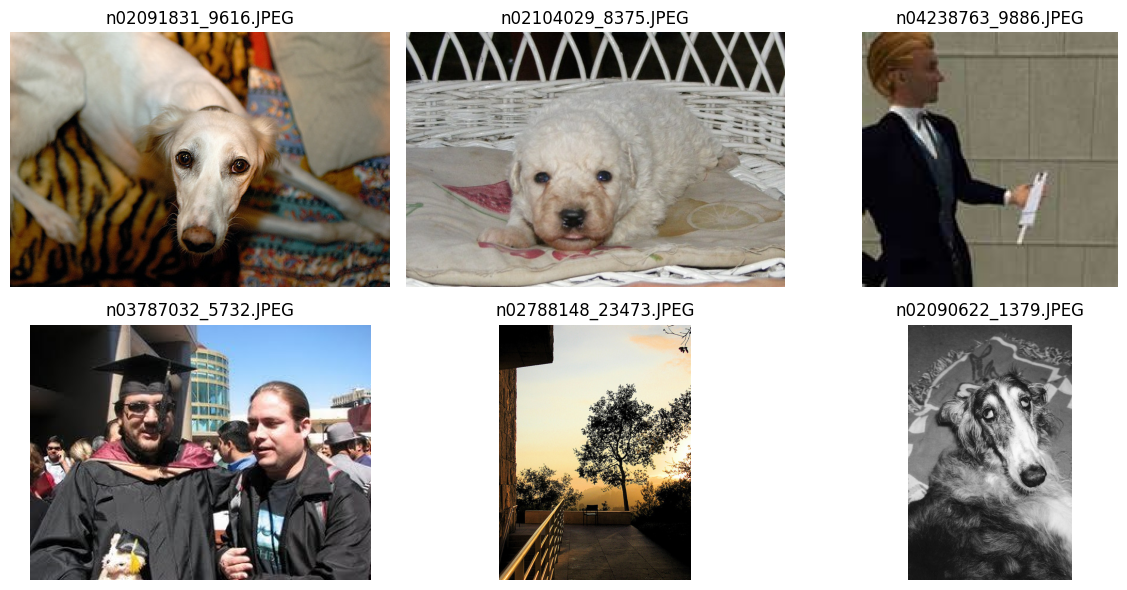

In [4]:
import random, cv2
import matplotlib.pyplot as plt

sample = random.sample(paths, k=min(6, len(paths)))
plt.figure(figsize=(12,6))
for i, p in enumerate(sample):
    img = cv2.imread(p)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(p.split("/")[-1])
    plt.axis("off")
plt.tight_layout()
plt.show()
